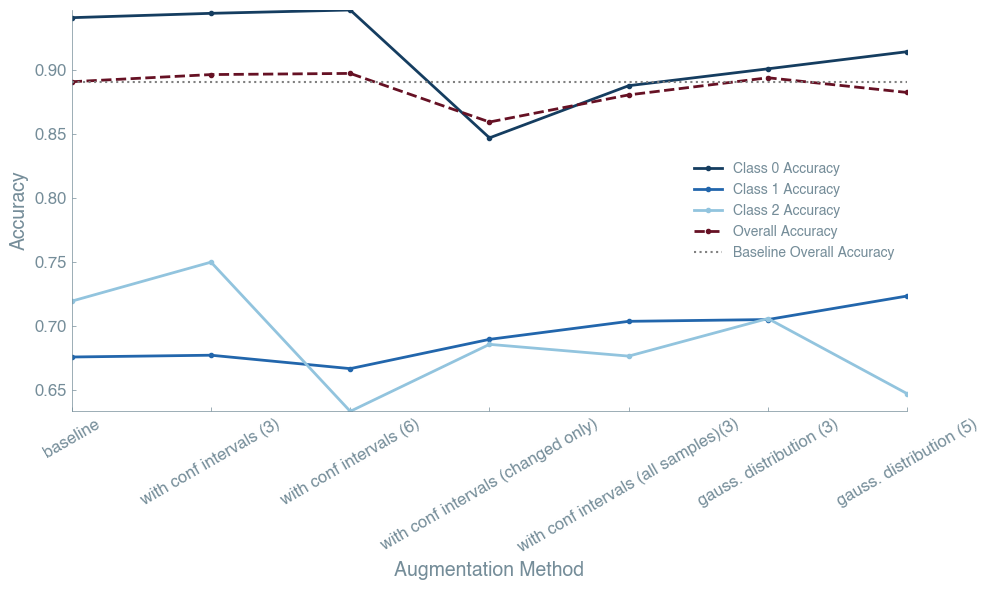

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# Load JSON-like data
data = [
  {
    "method": "baseline",
    "class_0_acc": 0.9412,
    "class_1_acc": 0.6758,
    "class_2_acc": 0.7195,
    "overall_weighted_acc": 0.8911
  },
  {
    "method": "with conf intervals (3)",
    "class_0_acc": 0.9446,
    "class_1_acc": 0.6772,
    "class_2_acc": 0.75,
    "overall_weighted_acc": 0.8967
  },
  {
    "method": "with conf intervals (6)",
    "class_0_acc": 0.9472,
    "class_1_acc": 0.6667,
    "class_2_acc": 0.6333,
    "overall_weighted_acc": 0.8976
  },
  {
    "method": "with conf intervals (changed only)",
    "class_0_acc": 0.8472,
    "class_1_acc": 0.6896,
    "class_2_acc": 0.6857,
    "overall_weighted_acc": 0.8596
  },
  {
    "method": "with conf intervals (all samples)(3)",
    "class_0_acc": 0.8880,
    "class_1_acc": 0.7037,
    "class_2_acc": 0.6765,
    "overall_weighted_acc": 0.8808
  },
  {
    "method": "gauss. distribution (3)",
    "class_0_acc": 0.9012,
    "class_1_acc": 0.7051,
    "class_2_acc": 0.7059,
    "overall_weighted_acc": 0.8942
  },
  {
    "method": "gauss. distribution (5)",
    "class_0_acc": 0.9146,
    "class_1_acc": 0.7235,
    "class_2_acc": 0.6471,
    "overall_weighted_acc": 0.8827
  }
]


df = pd.DataFrame(data)

plt.style.use('lamalab.mplstyle')
# Plot
plt.figure(figsize=(10, 6))
plt.plot(df["method"], df["class_0_acc"], marker='o', label="Class 0 Accuracy", color='#153d60', linewidth=2)
plt.plot(df["method"], df["class_1_acc"], marker='o', label="Class 1 Accuracy", color='#2266ac', linewidth=2)
plt.plot(df["method"], df["class_2_acc"], marker='o', label="Class 2 Accuracy", color='#92c4de', linewidth=2)
plt.plot(df["method"], df["overall_weighted_acc"], marker='o', linestyle='--', label="Overall Accuracy", color='#661124', linewidth=2)

baseline_acc = df.loc[df['method'] == 'baseline', 'overall_weighted_acc'].values[0]
plt.axhline(y=baseline_acc, linestyle=':', color='gray', label='Baseline Overall Accuracy', linewidth=1.5)

plt.xticks(rotation=30, fontsize=12)
plt.yticks(fontsize=12)

plt.ylabel("Accuracy", fontsize=14)
plt.xlabel("Augmentation Method", fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('augmentation_comp.png')
plt.show()


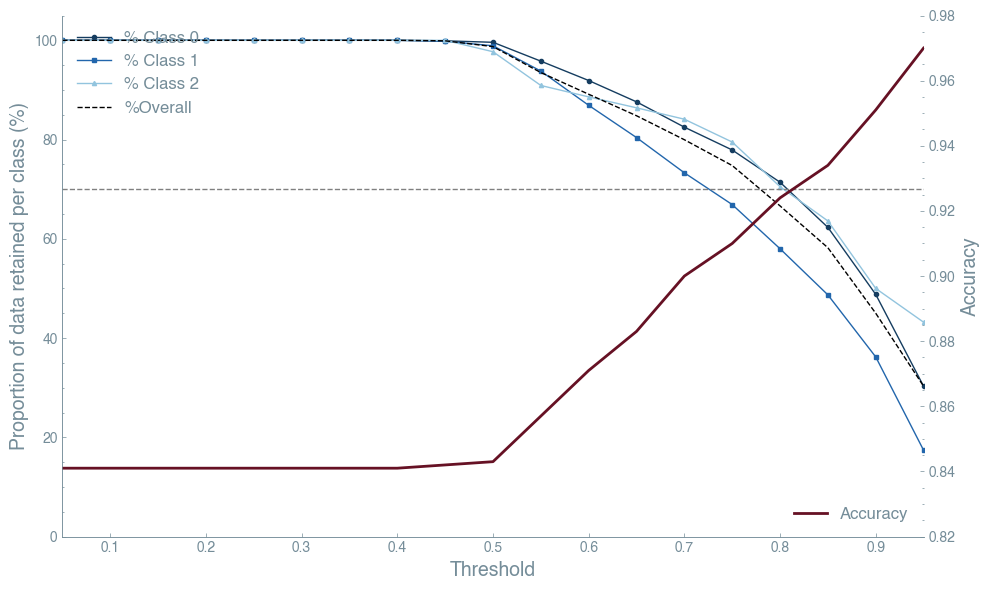

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Input data
data = {
    "Threshold": [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50,
                  0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95],
    "%C0": [100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 99.9, 99.6,
            95.8, 91.9, 87.6, 82.5, 77.9, 71.4, 62.3, 48.8, 30.3],
    "%C1": [100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 99.8, 98.9,
            93.8, 86.9, 80.4, 73.3, 66.9, 58.0, 48.7, 36.2, 17.4],
    "%C2": [100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 97.7,
            90.9, 88.6, 86.4, 84.1, 79.5, 70.5, 63.6, 50.0, 43.2],
    "Accuracy": [0.841, 0.841, 0.841, 0.841, 0.841, 0.841, 0.841, 0.841, 0.842, 0.843,
                 0.857, 0.871, 0.883, 0.900, 0.910, 0.924, 0.934, 0.951, 0.970]
}

df = pd.DataFrame(data)

# Calculate overall retention rate (mean across classes)
df["%Overall"] = df[["%C0", "%C1", "%C2"]].mean(axis=1)

# Create the plot with dual y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot percentage of data retained per class
ax1.plot(df["Threshold"], df["%C0"], label="% Class 0", marker="o", color='#153d60')
ax1.plot(df["Threshold"], df["%C1"], label="% Class 1", marker="s", color='#2266ac')
ax1.plot(df["Threshold"], df["%C2"], label="% Class 2", marker="^", color='#92c4de')
ax1.plot(df["Threshold"], df["%Overall"], label="%Overall", linestyle="--", color="black")

# Draw horizontal dashed line at 70%
ax1.axhline(y=70, linestyle="--", color="gray", linewidth=1)

# Axis labels and limits
ax1.set_xlabel("Threshold", fontsize=14)
ax1.set_ylabel("Proportion of data retained per class (%)", fontsize=14)
ax1.set_ylim(0, 105)
ax1.legend(loc="upper left", fontsize=12)

# Accuracy on secondary y-axis
ax2 = ax1.twinx()
ax2.plot(df["Threshold"], df["Accuracy"], label="Accuracy", color="#661124", linewidth=2)
ax2.set_ylabel("Accuracy", fontsize=14)
ax2.set_ylim(0.82, 0.98)
ax2.legend(loc="lower right", fontsize=12)

plt.tight_layout()
plt.savefig('conf_threshold.png')
plt.show()


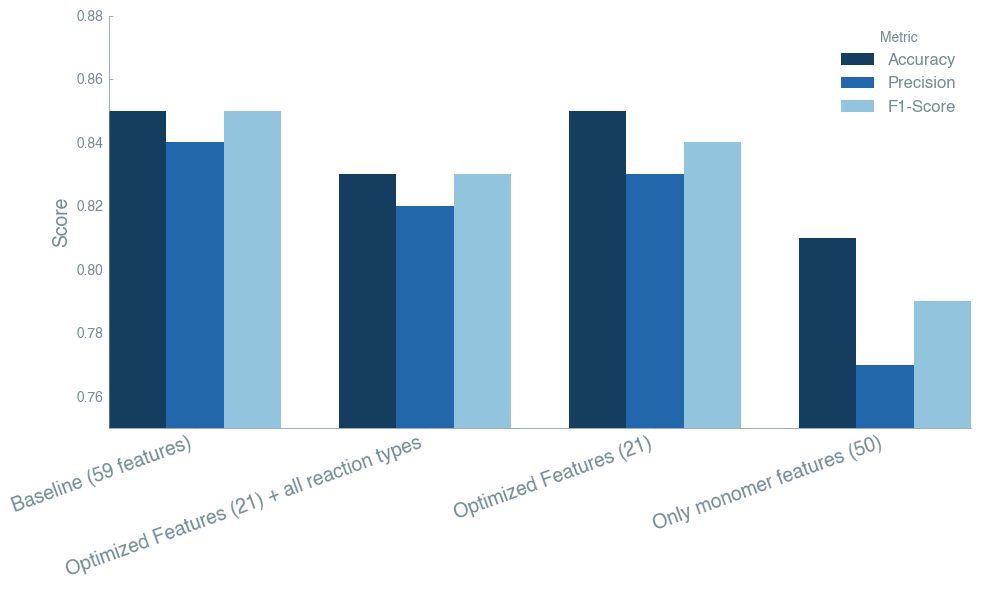

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Define the data
data = {
    "Baseline (59 features)": [0.85, 0.84, 0.85],
    "Optimized Features (21) + all reaction types": [0.83, 0.82, 0.83],
    "Optimized Features (21)": [0.85, 0.83, 0.84],
    "Only monomer features (50)": [0.81, 0.77, 0.79]
}

metrics = ["Accuracy", "Precision", "F1-Score"]
colors = ['#153d60', '#2266ac', '#92c4de']  # From previous plot

# Prepare bar positions
x = np.arange(len(data))  # One group per feature set
width = 0.25  # Width of each bar

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars for each metric
for i in range(3):
    values = [v[i] for v in data.values()]
    ax.bar(x + i * width - width, values, width=width, label=metrics[i], color=colors[i])

# Set x-axis labels and ticks
ax.set_xticks(x)
ax.set_xticklabels(data.keys(), rotation=20, ha='right', fontsize=14)
ax.set_ylabel("Score", fontsize=14)
ax.set_ylim(0.75, 0.88)
ax.legend(title="Metric", fontsize=12)

plt.tight_layout()
plt.savefig('feature_comp.png')
plt.show()


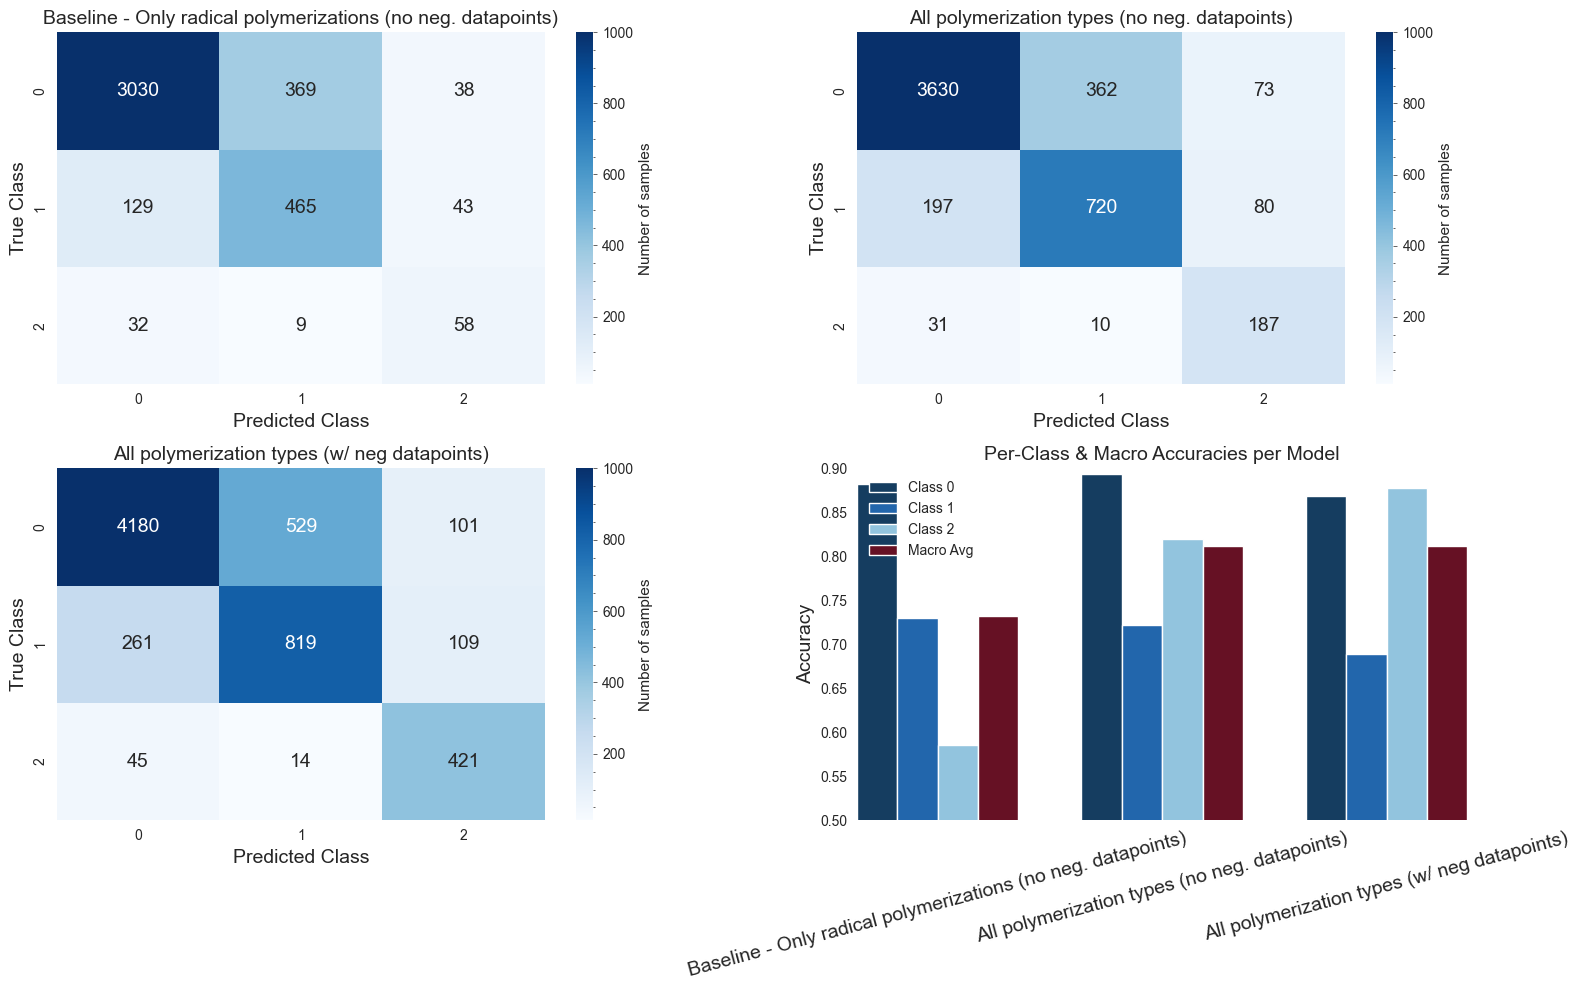

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# === Model labels ===
model_names = [
    "Baseline - Only radical polymerizations (no neg. datapoints)",
    "All polymerization types (no neg. datapoints)",
    "All polymerization types (w/ neg datapoints)"
]

# === Confusion Matrices ===
conf_matrices = [
    np.array([[3030, 369, 38], [129, 465, 43], [32, 9, 58]]),
    np.array([[3630, 362, 73], [197, 720, 80], [31, 10, 187]]),
    np.array([[4180, 529, 101], [261, 819, 109], [45, 14, 421]])
]

# === Per-class and macro accuracies ===
accuracies = {
    "Class 0": [0.8816, 0.8930, 0.8690],
    "Class 1": [0.7300, 0.7222, 0.6888],
    "Class 2": [0.5859, 0.8202, 0.8771],
    "Macro Avg": [0.7325, 0.8118, 0.8116]
}

# === Colors ===
model_colors = ['#153d60', '#2266ac', '#92c4de']
macro_color = '#661124'

# === Plot ===
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- 3 Confusion Matrices ---
for i, ax in enumerate(axes.flat[:3]):
    sns.heatmap(conf_matrices[i], annot=True, fmt='d',
            cmap="Blues", cbar=True, ax=ax, vmax=1000,
            annot_kws={'size': 14},
            cbar_kws={'label': 'Number of samples'})
    ax.set_title(f"{model_names[i]}", fontsize=14)
    ax.set_xlabel("Predicted Class", fontsize=14)
    ax.set_ylabel("True Class", fontsize=14)

# --- Barplot: Accuracy Comparison ---
ax = axes[1, 1]
bar_width = 0.18
x = np.arange(len(model_names))

# Plot class-wise bars
for i, cls in enumerate(["Class 0", "Class 1", "Class 2"]):
    acc_values = accuracies[cls]
    ax.bar(x + i * bar_width, acc_values, width=bar_width, label=cls, color=model_colors[i])

# Plot Macro Avg bars in a different color
macro_acc = accuracies["Macro Avg"]
ax.bar(x + 3 * bar_width, macro_acc, width=bar_width, label="Macro Avg", color=macro_color)

# Formatting
ax.set_xticks(x + 1.5 * bar_width)
ax.set_xticklabels(model_names, rotation=15, fontsize=14)
ax.set_ylim(0.5, 0.9)
ax.set_ylabel("Accuracy", fontsize=14)
ax.set_title("Per-Class & Macro Accuracies per Model", fontsize=14)
ax.legend()
ax.set_facecolor("white")
ax.grid(False) 

plt.tight_layout()

plt.savefig('output/comp_neg_datapoints.png')

plt.show()


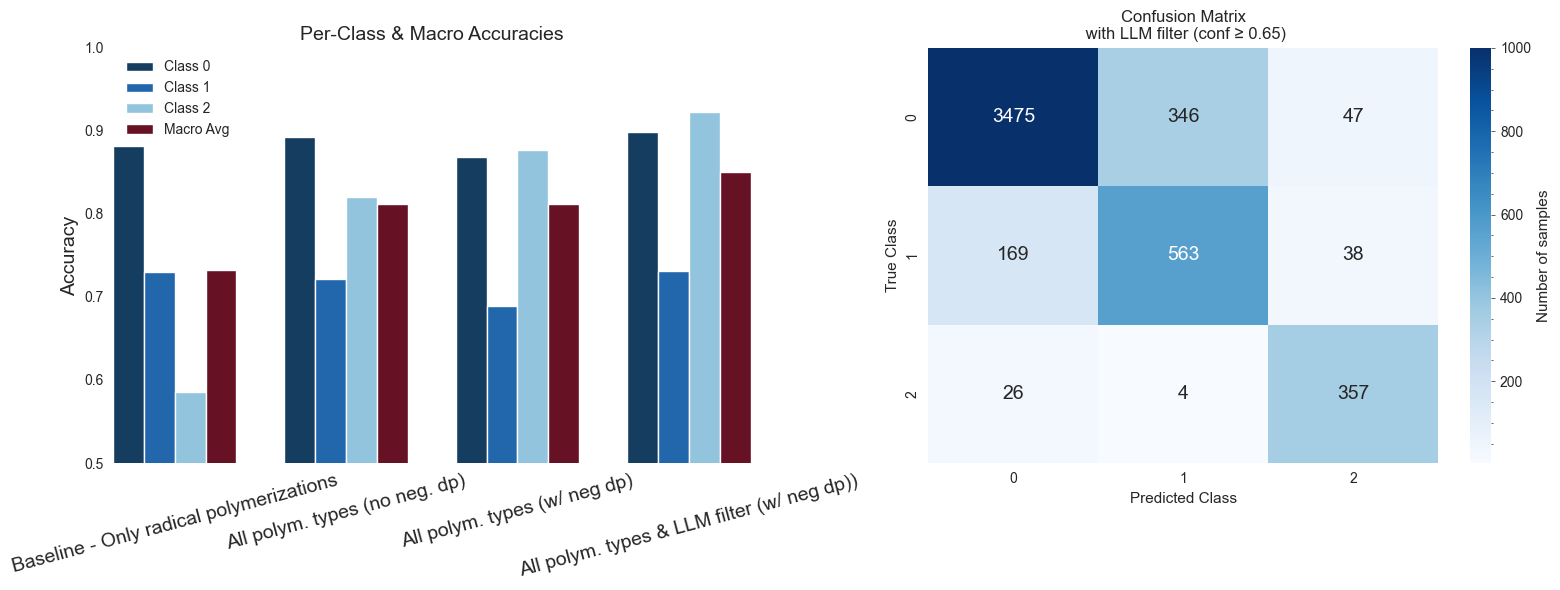

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# === Model names (previous + new) ===
model_names_ext = [
    "Baseline - Only radical polymerizations",
    "All polym. types (no neg. dp)",
    "All polym. types (w/ neg dp)",
    "All polym. types & LLM filter (w/ neg dp))"
]

# === Accuracies per class + macro avg ===
accuracies_ext = {
    "Class 0": [0.8816, 0.8930, 0.8690, 0.8984],
    "Class 1": [0.7300, 0.7222, 0.6888, 0.7312],
    "Class 2": [0.5859, 0.8202, 0.8771, 0.9225],
    "Macro Avg": [0.7325, 0.8118, 0.8116, 0.8507]
}

# === Confusion matrix for the new model ===
new_conf_mat = np.array([
    [3475, 346,  47],
    [ 169, 563,  38],
    [  26,   4, 357]
])

# === Colors ===
class_colors = ['#153d60', '#2266ac', '#92c4de']  # for Class 0, 1, 2
macro_color  = '#661124'                          # for Macro Avg

# === Create figure with 2 subplots ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.subplots_adjust(wspace=0.35)

# --- Left subplot: Bar plot ---
ax_bar = axes[0]
bar_width = 0.18
x = np.arange(len(model_names_ext))

# Plot class-wise bars
for i, cls in enumerate(["Class 0", "Class 1", "Class 2"]):
    ax_bar.bar(x + i * bar_width, accuracies_ext[cls],
               width=bar_width, label=cls, color=class_colors[i])

# Macro Avg bars
ax_bar.bar(x + 3 * bar_width, accuracies_ext["Macro Avg"],
           width=bar_width, label="Macro Avg", color=macro_color)

# Styling for bar plot
ax_bar.set_xticks(x + 1.5 * bar_width)
ax_bar.set_xticklabels(model_names_ext, rotation=15, fontsize=14)
ax_bar.set_ylim(0.5, 1.0)
ax_bar.set_ylabel("Accuracy", fontsize=14)
ax_bar.set_title("Per-Class & Macro Accuracies", fontsize=14)
ax_bar.legend()

# White background and no grid
ax_bar.set_facecolor("white")
ax_bar.grid(False)

# --- Right subplot: Heatmap of new confusion matrix ---
ax_hm = axes[1]
sns.heatmap(new_conf_mat, annot=True, fmt='d',
            cmap="Blues", cbar=True, ax=ax_hm, vmax=1000,
            annot_kws={'size': 14},
            cbar_kws={'label': 'Number of samples'})
ax_hm.set_title("Confusion Matrix\n with LLM filter (conf ≥ 0.65)", fontsize=12)
ax_hm.set_xlabel("Predicted Class")
ax_hm.set_ylabel("True Class")
ax_hm.set_facecolor("white")  # to match bar plot

plt.tight_layout()

plt.savefig('output/llm_filter_results_comp.jpg')

plt.show()
